# Simplecticidad de las trayectorias GC proyectadas y evolución del área

El integrador evoluciona dos copias internas y devuelve su promedio. La proyección $P:\mathbb{R}^{4N}\to\mathbb{R}^{2N}$ es rectangular y no puede ser simpléctica por sí sola. El objeto físico que estudia este notebook es el mapa acumulado

$$G_n=P\,\Phi_n\cdots\Phi_1\,E,$$

donde $E(z)=(z,z)$ sitúa la condición inicial sobre la diagonal, $\Phi_i$ son las etapas extendidas y $P(z_1,z_2)=(z_1+z_2)/2$. Su jacobiano $DG_n$ sí es cuadrado y se compara con la forma simpléctica física mediante

$$D_n=(DG_n)^T\Omega_{GC}DG_n-\Omega_{GC}.$$

Simultáneamente se observa el área del polígono proyectado y la separación entre las copias internas. Se usa `check_energy=False` porque este diagnóstico requiere exactamente el estado duplicado de tamaño $4N$.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np


def find_project_root(start):
    """Find the project whether Jupyter starts at its root or a notebook folder."""
    location = Path(start).resolve()
    for candidate in (location, *location.parents):
        if (candidate / 'pyproject.toml').is_file():
            return candidate
    raise RuntimeError('No se encontró la raíz del proyecto.')


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from classes import Area, Potential, SystemGC
from research.projection import ProjectedSymplecticityAreaObserver

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / 'notebooks'
    / 'developements'
    / 'study_gc_projected_symplecticity_area.ipynb'
)

In [2]:
potential = Potential.random(
    A=0.7,
    M=8,
    nx=32,
    ny=32,
    seed=27,
    interpolation_order=5,
)
center = (
    potential.grid.xmin + potential.grid.period / 2,
    potential.grid.ymin + potential.grid.period / 2,
)
# Ocho vértices mantienen asequible el jacobiano extendido de 32 x 32.
area = Area.circle(
    center=center,
    radius=0.5,
    points=8,
    rho=0.3,
)

# La frecuencia nula permite observar con claridad el efecto de la proyección.
# Puede sustituirse por np.pi / 8 para comparar el acoplamiento de las copias.
coupling_frequency = 0.0
system = SystemGC(
    potential,
    area,
    coupling_frequency=coupling_frequency,
)

In [ ]:
integration_step = 0.02
t_span = (0.0, 0.5)
n_save_step = 6

with ProjectedSymplecticityAreaObserver(
    notebook_path=NOTEBOOK_PATH,
    area=area,
    period=potential.grid.period,
    project_root=PROJECT_ROOT,
    block_name='projected_symplecticity',
    record_every=1,
    chunk_size=3,
    verbose=True,
    metadata={
        'coupling_frequency': coupling_frequency,
        'rho': area.rho,
        'shape': area.shape,
        'integration_step': integration_step,
        'potential_seed': 27,
    },
) as observer:
    solution = system.simulate(
        step=integration_step,
        t_span=t_span,
        n_save_step=n_save_step,
        check_energy=False,
        progress=False,
        stage_observer=observer,
    )

records = observer.records
output_blocks = observer.output_blocks
print(f'Observaciones físicas: {len(records)}')
print(f'Salida: {observer.output_directory}')
for block in output_blocks:
    print(
        f'Bloque {block.index:05d}: {block.sample_count} proyecciones -> ' 
        f'{block.jacobians_path.name}'
    )

[projected] step=-0001 t=0 relative_defect=0.000e+00 relative_area_error=+0.000e+00 copy_separation=0.000e+00
[projected] step=00000 t=0.02 relative_defect=3.939e-11 relative_area_error=-6.926e-06 copy_separation=1.377e-11
[projected] step=00001 t=0.04 relative_defect=5.156e-11 relative_area_error=-4.056e-05 copy_separation=2.694e-11
[projected] step=00002 t=0.06 relative_defect=5.992e-11 relative_area_error=-9.838e-05 copy_separation=3.951e-11
[projected] step=00003 t=0.08 relative_defect=7.025e-11 relative_area_error=-1.777e-04 copy_separation=5.175e-11
[projected] step=00004 t=0.1 relative_defect=7.252e-11 relative_area_error=-2.758e-04 copy_separation=6.349e-11
Observaciones físicas: 6
Salida: /home/juan/Proyectos/GC2D_intranet/outputs/developements/study_gc_projected_symplecticity_area/2026-07-20
Bloque 00002: 3 proyecciones -> projected_symplecticity_jacobians_00002.npz
Bloque 00003: 3 proyecciones -> projected_symplecticity_jacobians_00003.npz


## Salidas del estudio

Los resultados se guardan según la carpeta del notebook, su nombre y la fecha:

```text
outputs/developements/study_gc_projected_symplecticity_area/AAAA-MM-DD/
├── projected_symplecticity_summary_00000.csv
├── projected_symplecticity_jacobians_00000.npz
└── projected_symplecticity_metadata_00000.json
```

Cada NPZ contiene los jacobianos físicos acumulados y los estados proyectados del mismo bloque. Los índices continúan en ejecuciones posteriores, sin sobrescribir resultados.

In [4]:
print(
    f"{'step':>6} {'t':>9} {'defecto rel.':>16} "
    f"{'error área rel.':>18} {'separación':>14}"
)
for record in records:
    print(
        f'{record.step_index:6d} {record.time:9.5f} '
        f'{record.relative_defect:16.8e} '
        f'{record.relative_area_error:18.8e} '
        f'{record.copy_separation:14.6e}'
    )

  step         t     defecto rel.    error área rel.     separación
    -1   0.00000   0.00000000e+00     0.00000000e+00   0.000000e+00
     0   0.02000   3.93923154e-11    -6.92608807e-06   1.376795e-11
     1   0.04000   5.15598287e-11    -4.05594771e-05   2.694435e-11
     2   0.06000   5.99192236e-11    -9.83756089e-05   3.951039e-11
     3   0.08000   7.02510285e-11    -1.77725495e-04   5.174887e-11
     4   0.10000   7.25201243e-11    -2.75849369e-04   6.348849e-11


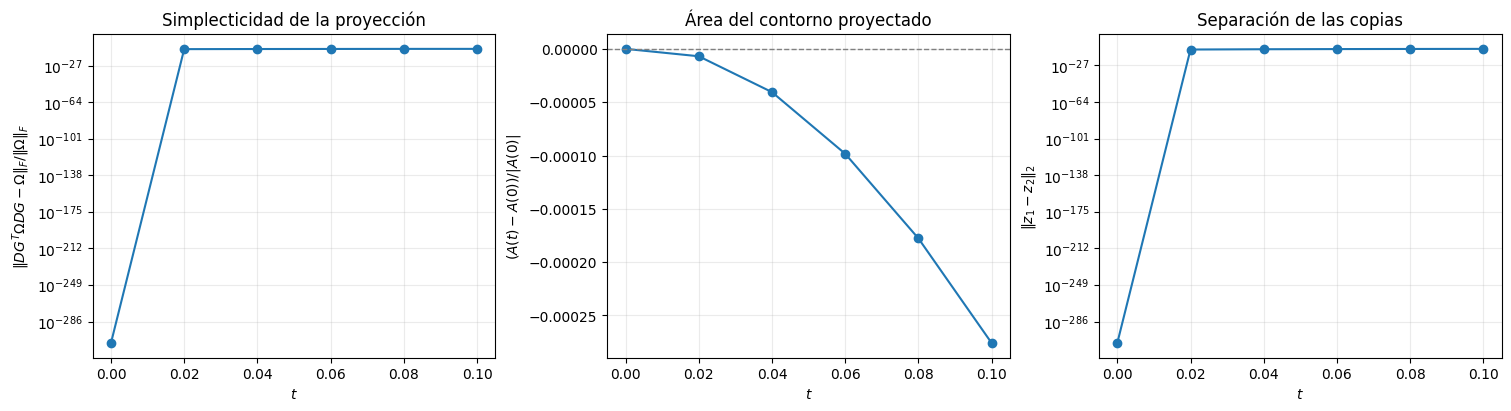

In [5]:
times = np.asarray([record.time for record in records])
relative_defects = np.asarray([record.relative_defect for record in records])
relative_area_errors = np.asarray(
    [record.relative_area_error for record in records]
)
copy_separations = np.asarray([record.copy_separation for record in records])
positive_floor = np.finfo(float).tiny

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
axes[0].semilogy(times, np.maximum(relative_defects, positive_floor), 'o-')
axes[0].set(
    title='Simplecticidad de la proyección',
    xlabel='$t$',
    ylabel=r'$\|DG^T\Omega DG-\Omega\|_F/\|\Omega\|_F$',
)
axes[1].plot(times, relative_area_errors, 'o-')
axes[1].axhline(0.0, color='0.5', ls='--', lw=1)
axes[1].set(
    title='Área del contorno proyectado',
    xlabel='$t$',
    ylabel=r'$(A(t)-A(0))/|A(0)|$',
)
axes[2].semilogy(times, np.maximum(copy_separations, positive_floor), 'o-')
axes[2].set(
    title='Separación de las copias',
    xlabel='$t$',
    ylabel=r'$\|z_1-z_2\|_2$',
)
for axis in axes:
    axis.grid(alpha=0.25)
plt.show()

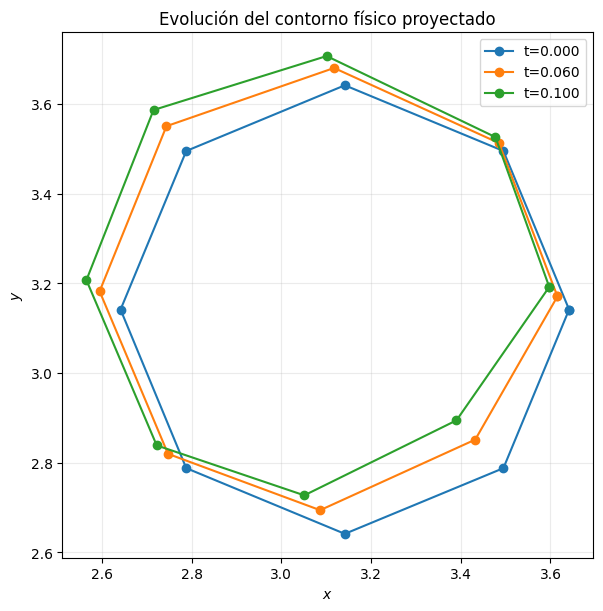

In [6]:
components = solution.components()
fig, axis = plt.subplots(figsize=(6, 6), constrained_layout=True)
for index in (0, len(solution.t) // 2, len(solution.t) - 1):
    x = components.x[:, index]
    y = components.y[:, index]
    axis.plot(
        np.r_[x, x[0]],
        np.r_[y, y[0]],
        marker='o',
        label=f't={solution.t[index]:.3f}',
    )
axis.set(
    title='Evolución del contorno físico proyectado',
    xlabel='$x$',
    ylabel='$y$',
    aspect='equal',
)
axis.grid(alpha=0.25)
axis.legend()
plt.show()

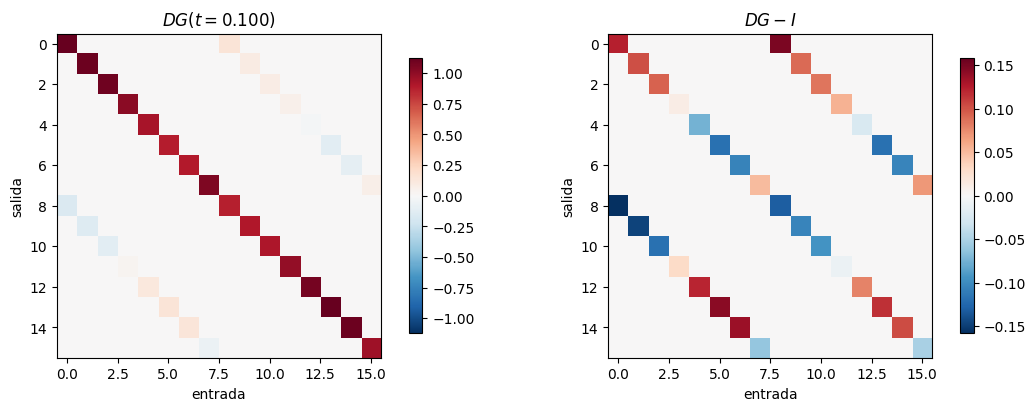

In [7]:
stored_jacobians = []
stored_times = []
for block in output_blocks:
    with np.load(block.jacobians_path) as stored:
        stored_jacobians.append(stored['projected_jacobians'].copy())
        stored_times.append(stored['times'].copy())
projected_jacobians = np.concatenate(stored_jacobians)
jacobian_times = np.concatenate(stored_times)

final_jacobian = projected_jacobians[-1]
difference = final_jacobian - np.eye(final_jacobian.shape[0])
limit = max(float(np.max(np.abs(final_jacobian))), 1.0)
difference_limit = max(float(np.max(np.abs(difference))), np.finfo(float).eps)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
images = [
    axes[0].imshow(final_jacobian, cmap='RdBu_r', vmin=-limit, vmax=limit),
    axes[1].imshow(
        difference,
        cmap='RdBu_r',
        vmin=-difference_limit,
        vmax=difference_limit,
    ),
]
axes[0].set(title=fr'$DG(t={jacobian_times[-1]:.3f})$', xlabel='entrada', ylabel='salida')
axes[1].set(title=r'$DG-I$', xlabel='entrada', ylabel='salida')
for axis, image in zip(axes, images, strict=True):
    fig.colorbar(image, ax=axis, shrink=0.85)
plt.show()

## Interpretación

El defecto simpléctico caracteriza la sensibilidad del mapa físico proyectado respecto a la condición inicial. El error de área mide el polígono formado por un número finito de vértices. Ambas magnitudes están relacionadas, pero no tienen por qué coincidir exactamente: incluso un flujo continuo que preserve área puede curvar los lados entre vértices y cambiar el área de su aproximación poligonal. La separación $\|z_1-z_2\|$ ayuda a distinguir cuánto del defecto observado procede de proyectar dos copias que ya no están sobre la diagonal.